In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timezone, timedelta
from dataclasses import asdict
import json, tempfile, joblib

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
import mlflow

from data_generator.ups_inverter_simulator import InverterSimulator

# Generate 48h of inverter data with frequent islanding events
inv_sim = InverterSimulator(
    num_inverters=6,
    islanding_probability=0.08,   # higher to get enough transitioning samples
    datacenter_zone="ZONE-A"
)

start_time = datetime(2024, 6, 15, 0, 0, tzinfo=timezone.utc)
records = []
for i in range(576):  # 48h at 5-min intervals
    ts = start_time + timedelta(minutes=5 * i)
    records.extend([asdict(r) for r in inv_sim.generate_snapshot(ts)])

df = pd.DataFrame(records)
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'], utc=True)
df['hour'] = df['timestamp_utc'].dt.hour

print(f'Total records  : {len(df):,}')
print(f'\nControl mode distribution:')
print(df['control_mode'].value_counts())
print(f'\nIslanding events: {df["islanding_detected"].sum():,}')

2026-03-02 20:01:53.406 | INFO     | data_generator.ups_inverter_simulator:__init__:222 - InverterSimulator: 6 inverters in ZONE-A


Total records  : 3,456

Control mode distribution:
control_mode
GFM              3436
transitioning      13
GFL                 7
Name: count, dtype: int64

Islanding events: 976


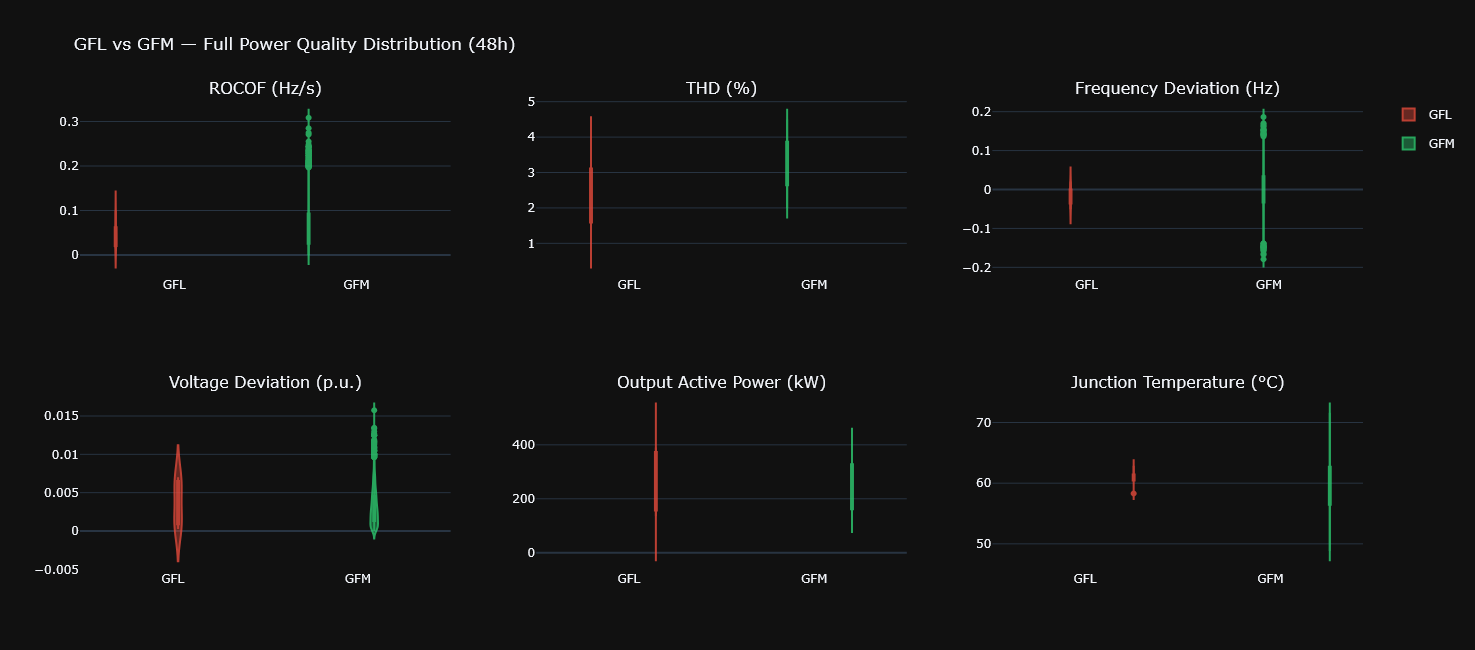

=== GFL vs GFM Statistical Summary ===
             rocof_hz_per_s                 thd_percent               freq_deviation_hz                 voltage_deviation_pu                
                       mean     std     max        mean     std   max              mean     std     max                 mean     std     max
control_mode                                                                                                                                
GFL                  0.0448  0.0301  0.0993      2.2257  0.8297  3.37           -0.0149  0.0249  0.0206               0.0036  0.0029  0.0070
GFM                  0.0640  0.0488  0.3083      3.2480  0.7181  4.50            0.0004  0.0507  0.1865               0.0032  0.0024  0.0158


In [8]:
df_gfx = df[df['control_mode'].isin(['GFL', 'GFM'])].copy()

fig = make_subplots(rows=2, cols=3, subplot_titles=[
    'ROCOF (Hz/s)',
    'THD (%)',
    'Frequency Deviation (Hz)',
    'Voltage Deviation (p.u.)',
    'Output Active Power (kW)',
    'Junction Temperature (°C)'
])

metrics = [
    ('rocof_hz_per_s',          1, 1),
    ('thd_percent',             1, 2),
    ('freq_deviation_hz',       1, 3),
    ('voltage_deviation_pu',    2, 1),
    ('output_active_power_kw',  2, 2),
    ('junction_temp_c',         2, 3),
]
colors = {'GFL': '#e74c3c', 'GFM': '#2ecc71'}

for metric, row, col in metrics:
    for mode in ['GFL', 'GFM']:
        vals = df_gfx[df_gfx['control_mode'] == mode][metric]
        fig.add_trace(go.Violin(
            y=vals, name=mode, legendgroup=mode,
            showlegend=(row == 1 and col == 1),
            marker_color=colors[mode], box_visible=True,
            meanline_visible=True, opacity=0.8
        ), row=row, col=col)

fig.update_layout(
    height=650, template='plotly_dark',
    title='GFL vs GFM — Full Power Quality Distribution (48h)',
    violinmode='group'
)
fig.show()

# Statistical summary
print('=== GFL vs GFM Statistical Summary ===')
print(df_gfx.groupby('control_mode')[[
    'rocof_hz_per_s', 'thd_percent',
    'freq_deviation_hz', 'voltage_deviation_pu'
]].agg(['mean', 'std', 'max']).round(4).to_string())

In [9]:
# Include all three classes (GFL, GFM, transitioning)
ALL_MODES = ['GFL', 'GFM', 'transitioning']
df_model  = df[df['control_mode'].isin(ALL_MODES)].copy()

print('Class distribution (including transitioning):')
print(df_model['control_mode'].value_counts())

# Features
FEATURES = [
    'rocof_hz_per_s',
    'thd_percent',
    'freq_deviation_hz',
    'voltage_deviation_pu',
    'output_active_power_kw',
    'output_reactive_power_kvar',
    'output_voltage_v',
    'output_frequency_hz',
    'dc_link_voltage_v',
    'junction_temp_c',
    'efficiency',
    'gfl_pll_locked',
]

# Rolling features per inverter
df_model = df_model.sort_values(['inverter_id', 'timestamp_utc'])
df_model['rocof_roll_mean'] = (df_model.groupby('inverter_id')['rocof_hz_per_s']
                                .transform(lambda x: x.rolling(4, min_periods=1).mean()))
df_model['rocof_roll_std']  = (df_model.groupby('inverter_id')['rocof_hz_per_s']
                                .transform(lambda x: x.rolling(4, min_periods=1).std().fillna(0)))
df_model['freq_roll_std']   = (df_model.groupby('inverter_id')['freq_deviation_hz']
                                .transform(lambda x: x.rolling(4, min_periods=1).std().fillna(0)))

ALL_FEATURES = FEATURES + ['rocof_roll_mean', 'rocof_roll_std', 'freq_roll_std']

# Encode labels
le = LabelEncoder()
y  = le.fit_transform(df_model['control_mode'])
X  = df_model[ALL_FEATURES].astype(float).values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'Feature matrix : {X_scaled.shape}')

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Train model
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("gfm-gfl-classifier")

with mlflow.start_run(run_name="random_forest_multiclass_v1"):

    clf = RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(X_train, y_train)

    y_pred  = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)

    # Metrics
    report    = classification_report(y_test, y_pred,
                                      target_names=le.classes_,
                                      output_dict=True)
    auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(clf, X_scaled, y, cv=cv,
                            scoring='f1_macro', n_jobs=-1)

    mlflow.log_params({
        "model":        "RandomForestClassifier",
        "n_estimators": 300,
        "n_classes":    3,
        "n_features":   len(ALL_FEATURES),
        "class_weight": "balanced",
    })
    mlflow.log_metrics({
        "auc_macro":    round(auc_macro, 4),
        "cv_f1_macro":  round(cv_f1.mean(), 4),
        "cv_f1_std":    round(cv_f1.std(), 4),
        "f1_GFL":       round(report['GFL']['f1-score'], 4),
        "f1_GFM":       round(report['GFM']['f1-score'], 4),
        "f1_transitioning": round(report['transitioning']['f1-score'], 4),
    })

    with tempfile.TemporaryDirectory() as tmp:
        joblib.dump(clf,    os.path.join(tmp, "gfm_classifier.pkl"))
        joblib.dump(scaler, os.path.join(tmp, "gfm_scaler.pkl"))
        joblib.dump(le,     os.path.join(tmp, "gfm_label_encoder.pkl"))
        mlflow.log_artifacts(tmp, artifact_path="model")

print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))
print(f'AUC Macro (OvR) : {auc_macro:.4f}')
print(f'CV F1 Macro     : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

Class distribution (including transitioning):
control_mode
GFM              3436
transitioning      13
GFL                 7
Name: count, dtype: int64

Label encoding: {'GFL': np.int64(0), 'GFM': np.int64(1), 'transitioning': np.int64(2)}
Feature matrix : (3456, 15)


C:\ProgramData\anaconda3\envs\coding\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\ProgramData\anaconda3\envs\coding\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\ProgramData\anaconda3\envs\coding\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



🏃 View run random_forest_multiclass_v1 at: http://localhost:5000/#/experiments/167145669308850546/runs/10bd98de992a4bdf9395d5256413520d
🧪 View experiment at: http://localhost:5000/#/experiments/167145669308850546
=== CLASSIFICATION REPORT ===


C:\ProgramData\anaconda3\envs\coding\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\ProgramData\anaconda3\envs\coding\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\ProgramData\anaconda3\envs\coding\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



               precision    recall  f1-score   support

          GFL       0.00      0.00      0.00         1
          GFM       1.00      1.00      1.00       688
transitioning       1.00      1.00      1.00         3

     accuracy                           1.00       692
    macro avg       0.67      0.67      0.67       692
 weighted avg       1.00      1.00      1.00       692

AUC Macro (OvR) : 0.9867
CV F1 Macro     : 0.6663 ± 0.0001


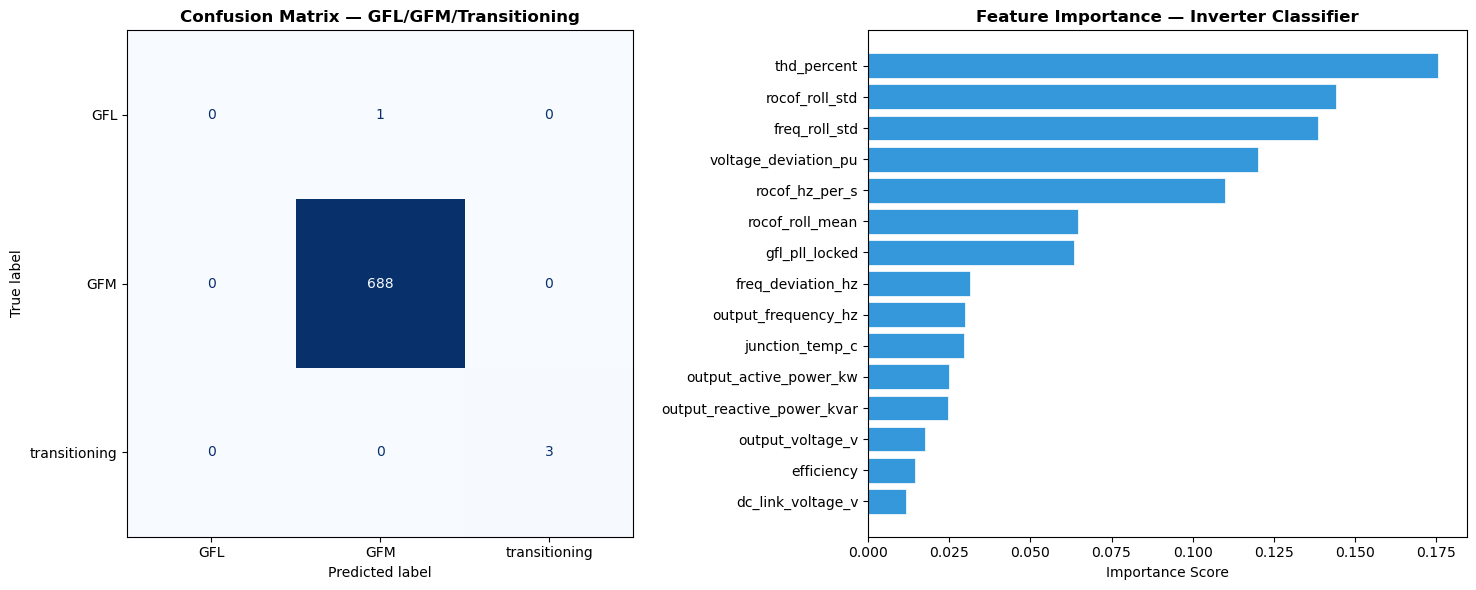

Top 5 most important features:
             feature  importance
      rocof_hz_per_s    0.109926
voltage_deviation_pu    0.120022
       freq_roll_std    0.138574
      rocof_roll_std    0.144117
         thd_percent    0.175739


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — GFL/GFM/Transitioning', fontweight='bold')

# Feature importance
importance_df = pd.DataFrame({
    'feature':    ALL_FEATURES,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(importance_df['feature'], importance_df['importance'],
             color='#3498db', edgecolor='white', linewidth=0.5)
axes[1].set_title('Feature Importance — Inverter Classifier', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('gfm_classifier_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
print(importance_df.tail(5)[['feature', 'importance']].to_string(index=False))

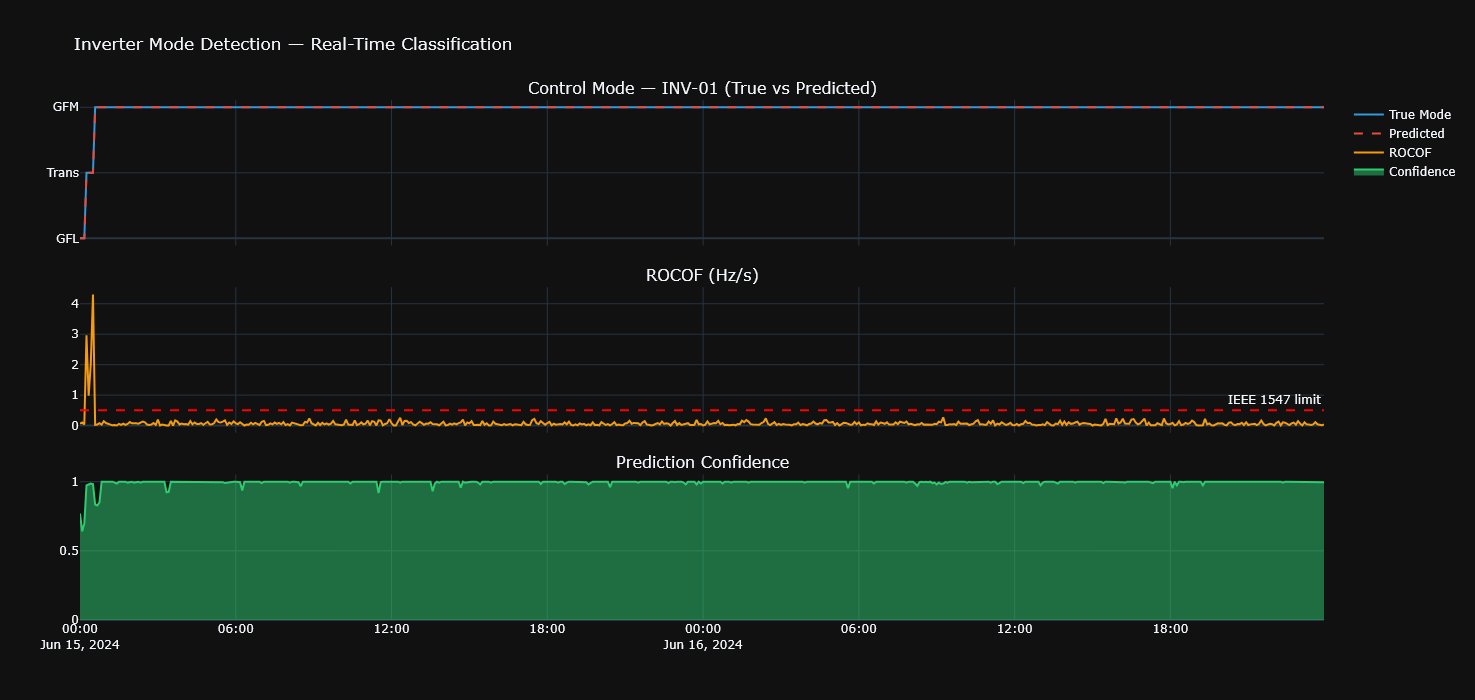

In [11]:
# Predict on full dataset and visualize GFL→GFM transitions
df_model['predicted_mode'] = le.inverse_transform(clf.predict(X_scaled))
df_model['pred_confidence'] = clf.predict_proba(X_scaled).max(axis=1)

# Sample one inverter for visualization
inv_id = df_model['inverter_id'].unique()[0]
df_inv0 = df_model[df_model['inverter_id'] == inv_id].copy()

fig = make_subplots(rows=3, cols=1, shared_xaxes=True, subplot_titles=[
    f'Control Mode — {inv_id} (True vs Predicted)',
    'ROCOF (Hz/s)',
    'Prediction Confidence'
], vertical_spacing=0.08)

mode_map = {'GFL': 0, 'transitioning': 1, 'GFM': 2}
fig.add_trace(go.Scatter(
    x=df_inv0['timestamp_utc'],
    y=df_inv0['control_mode'].map(mode_map),
    name='True Mode', line=dict(color='#3498db')), row=1, col=1)
fig.add_trace(go.Scatter(
    x=df_inv0['timestamp_utc'],
    y=df_inv0['predicted_mode'].map(mode_map),
    name='Predicted', line=dict(color='#e74c3c', dash='dash')), row=1, col=1)

fig.add_trace(go.Scatter(
    x=df_inv0['timestamp_utc'], y=df_inv0['rocof_hz_per_s'],
    name='ROCOF', line=dict(color='#f39c12')), row=2, col=1)
fig.add_hline(y=0.5, line_dash='dash', line_color='red',
              annotation_text='IEEE 1547 limit', row=2, col=1)

fig.add_trace(go.Scatter(
    x=df_inv0['timestamp_utc'], y=df_inv0['pred_confidence'],
    name='Confidence', fill='tozeroy',
    line=dict(color='#2ecc71')), row=3, col=1)

fig.update_yaxes(tickvals=[0,1,2], ticktext=['GFL','Trans','GFM'], row=1, col=1)
fig.update_layout(height=700, template='plotly_dark',
                  title='Inverter Mode Detection — Real-Time Classification')
fig.show()

In [12]:
os.makedirs('../ml', exist_ok=True)
joblib.dump(clf,    '../ml/gfm_classifier.pkl')
joblib.dump(scaler, '../ml/gfm_scaler.pkl')
joblib.dump(le,     '../ml/gfm_label_encoder.pkl')
with open('../ml/gfm_features.json', 'w') as f:
    json.dump(ALL_FEATURES, f)

print('Models saved to ml/')
print()
print('=' * 52)
print('THESIS SUMMARY — GFL vs GFM CLASSIFIER')
print('=' * 52)
print(f'  Dataset     : 48h simulation, {len(df_model):,} records')
print(f'  Classes     : GFL | GFM | Transitioning')
print(f'  AUC Macro   : {auc_macro:.4f}')
print(f'  CV F1 Macro : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print()
print('  Key finding:')
gfl_rocof = df_model[df_model['control_mode']=='GFL']['rocof_hz_per_s'].mean()
gfm_rocof = df_model[df_model['control_mode']=='GFM']['rocof_hz_per_s'].mean()
print(f'  GFL avg ROCOF during normal operation : {gfl_rocof:.4f} Hz/s')
print(f'  GFM avg ROCOF during normal operation : {gfm_rocof:.4f} Hz/s')
print(f'  ROCOF difference                      : {abs(gfl_rocof-gfm_rocof):.4f} Hz/s')

Models saved to ml/

THESIS SUMMARY — GFL vs GFM CLASSIFIER
  Dataset     : 48h simulation, 3,456 records
  Classes     : GFL | GFM | Transitioning
  AUC Macro   : 0.9867
  CV F1 Macro : 0.6663 ± 0.0001

  Key finding:
  GFL avg ROCOF during normal operation : 0.0448 Hz/s
  GFM avg ROCOF during normal operation : 0.0640 Hz/s
  ROCOF difference                      : 0.0192 Hz/s
